###  import  the  libraries    

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, auc, precision_recall_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries loaded ✅")   

Libraries loaded ✅


###  load  the  data sets    

In [2]:
df = pd.read_csv("../../data/processed/churn_cleaned.csv")

model = joblib.load("../models/churn_model.pkl")

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Model and data loaded ✅")
print(f"Model type: {type(model).__name__}")    

Model and data loaded ✅
Model type: RandomForestClassifier


In [3]:
###  train and  test   data    


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set: {X_test.shape[0]} customers")

Test set: 1409 customers


###  genarated  the  predicttion   

In [4]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Predictions generated ✅")   

Predictions generated ✅


###  classification   report  

In [5]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))   

              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



###  confusion  metrix    

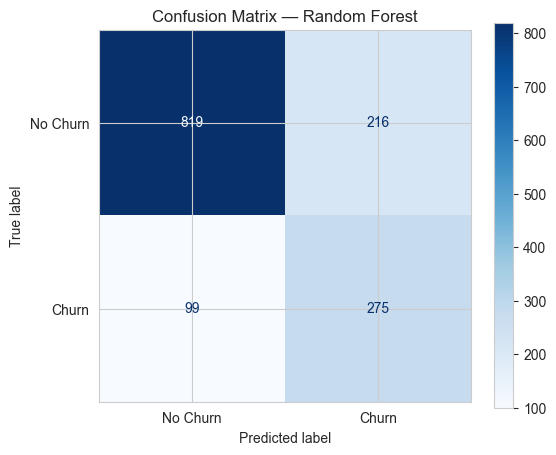

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Random Forest")
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()  

###  confusion  metrics   breakdown   

In [7]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (correctly predicted staying):  {tn}")
print(f"False Positives (predicted churn, actually stayed): {fp}  <- unnecessary retention offers")
print(f"False Negatives (predicted staying, actually churned): {fn}  <- missed at-risk customers (costly)")
print(f"True Positives  (correctly caught churners): {tp}")
print(f"\nOf {tp + fn} actual churners, we correctly identified {tp} ({tp/(tp+fn):.1%})")    

True Negatives  (correctly predicted staying):  819
False Positives (predicted churn, actually stayed): 216  <- unnecessary retention offers
False Negatives (predicted staying, actually churned): 99  <- missed at-risk customers (costly)
True Positives  (correctly caught churners): 275

Of 374 actual churners, we correctly identified 275 (73.5%)


###  ROC  curve   

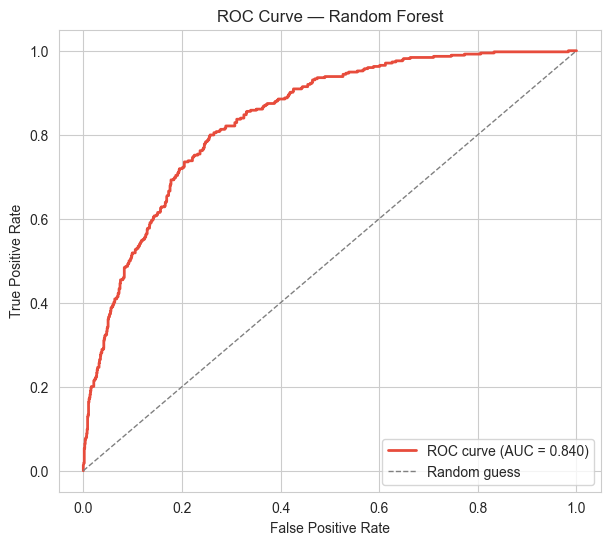

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#e74c3c", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend(loc="lower right")
plt.savefig("../outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()   

###  Precision-Recall curve    

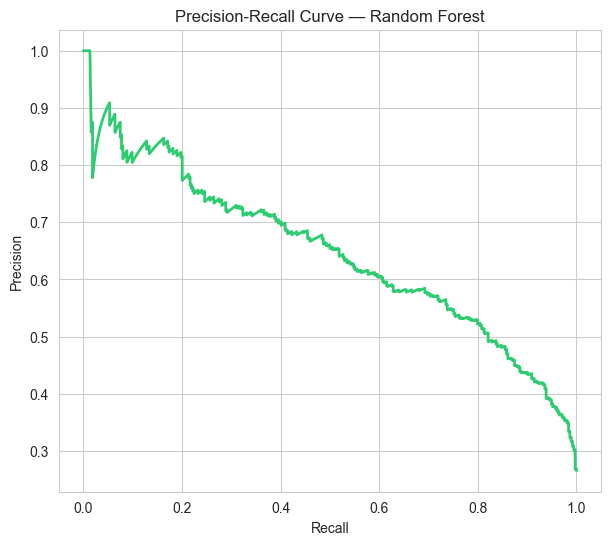

In [9]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color="#2ecc71", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Random Forest")
plt.savefig("../outputs/precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

###  Threshold analysis    

In [10]:
threshold_results = []
for t in np.arange(0.2, 0.8, 0.05):
    pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_t).ravel()
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    threshold_results.append({"Threshold": round(t, 2), "Precision": round(precision_t, 3), "Recall": round(recall_t, 3)})

threshold_df = pd.DataFrame(threshold_results)
threshold_df    

,Threshold,Precision,Recall
0,0.20,0.421,0.920
1,0.25,0.440,0.885
2,0.30,0.465,0.861
3,0.35,0.491,0.837
4,0.40,0.519,0.807
5,0.45,0.537,0.762
6,0.50,0.560,0.735
7,0.55,0.582,0.676
8,0.60,0.599,0.607
9,0.65,0.635,0.529


###  Plot the threshold tradeoff   

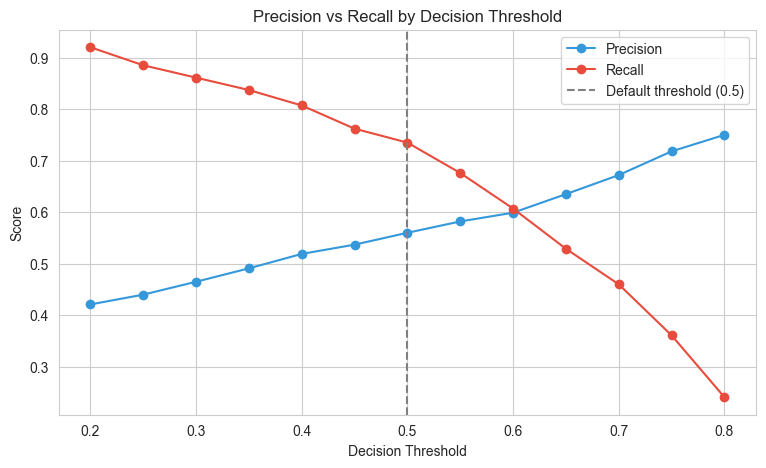

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision", color="#3498db")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall", color="#e74c3c")
plt.axvline(x=0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall by Decision Threshold")
plt.legend()
plt.savefig("../outputs/threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()    

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21256\3427290261.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, y="Feature", x="Importance", palette="viridis")


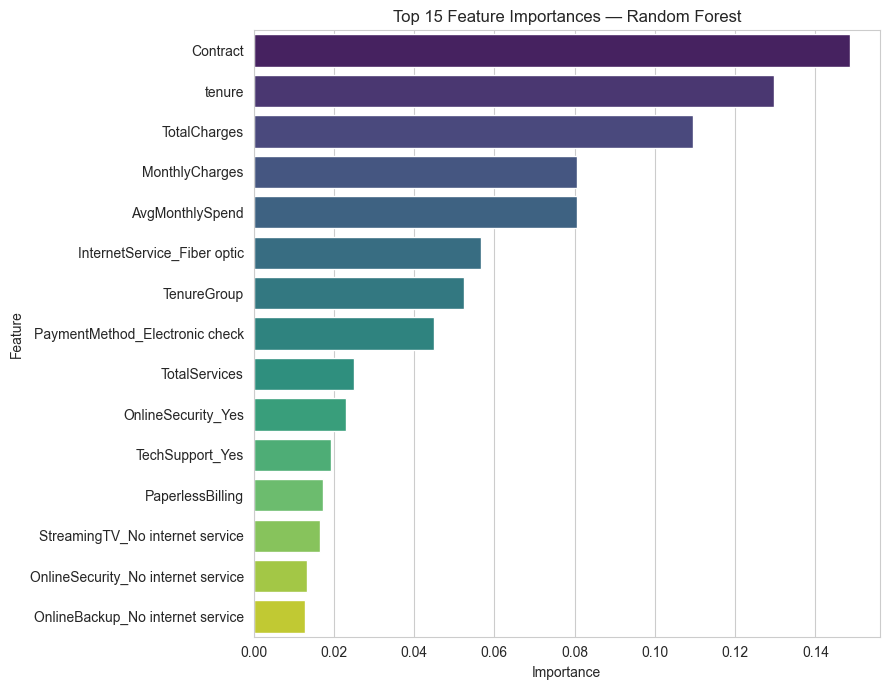

In [12]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(data=importances, y="Feature", x="Importance", palette="viridis")
plt.title("Top 15 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

###  Save feature importance as data for the dashboard/API   

In [13]:
importances_full = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importances_full.to_csv("../outputs/feature_importance.csv", index=False)
print("Feature importance saved ✅")
importances_full.head(10)

Feature importance saved ✅


,Feature,Importance
6,Contract,0.148642
4,tenure,0.129591
9,TotalCharges,0.109526
8,MonthlyCharges,0.080492
11,AvgMonthlySpend,0.080465
16,InternetService_Fiber optic,0.056765
10,TenureGroup,0.052533
31,PaymentMethod_Electronic check,0.044884
13,TotalServices,0.024956
19,OnlineSecurity_Yes,0.023035


###  Save all evaluation metrics as JSON     

In [14]:
evaluation_summary = {
    "model_name": "Random Forest (class_weight)",
    "test_set_size": int(X_test.shape[0]),
    "accuracy": float((y_pred == y_test).mean()),
    "precision": float(tp / (tp + fp)),
    "recall": float(tp / (tp + fn)),
    "f1_score": float(2 * (tp/(tp+fp)) * (tp/(tp+fn)) / ((tp/(tp+fp)) + (tp/(tp+fn)))),
    "roc_auc": float(roc_auc),
    "confusion_matrix": {
        "true_negative": int(tn), "false_positive": int(fp),
        "false_negative": int(fn), "true_positive": int(tp)
    },
    "top_10_features": importances_full.head(10).to_dict(orient="records")
}

with open("../models/evaluation_summary.json", "w") as f:
    json.dump(evaluation_summary, f, indent=2)

print("Evaluation summary saved ✅")
evaluation_summary

Evaluation summary saved ✅


{'model_name': 'Random Forest (class_weight)',
 'test_set_size': 1409,
 'accuracy': 0.7764371894960965,
 'precision': 0.75,
 'recall': 0.24064171122994651,
 'f1_score': 0.3643724696356275,
 'roc_auc': 0.8402722880983751,
 'confusion_matrix': {'true_negative': 1005,
  'false_positive': 30,
  'false_negative': 284,
  'true_positive': 90},
 'top_10_features': [{'Feature': 'Contract',
   'Importance': 0.14864218321688705},
  {'Feature': 'tenure', 'Importance': 0.1295909514130686},
  {'Feature': 'TotalCharges', 'Importance': 0.10952559158330147},
  {'Feature': 'MonthlyCharges', 'Importance': 0.08049154341783911},
  {'Feature': 'AvgMonthlySpend', 'Importance': 0.08046471203864762},
  {'Feature': 'InternetService_Fiber optic',
   'Importance': 0.056764860675688616},
  {'Feature': 'TenureGroup', 'Importance': 0.05253261415076767},
  {'Feature': 'PaymentMethod_Electronic check',
   'Importance': 0.0448841583799921},
  {'Feature': 'TotalServices', 'Importance': 0.024955507773194066},
  {'Feature

### Sample predictions for dashboard demo data

In [15]:
sample_predictions = X_test.copy()
sample_predictions["ActualChurn"] = y_test.values
sample_predictions["PredictedChurn"] = y_pred
sample_predictions["ChurnProbability"] = y_proba.round(3)

sample_predictions["RiskTier"] = pd.cut(
    sample_predictions["ChurnProbability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

sample_predictions.sort_values("ChurnProbability", ascending=False).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ActualChurn,PredictedChurn,ChurnProbability,RiskTier
4585,0,1,0,0,1,1,0.0,1,85.05,85.05,...,0.0,0.0,1.0,0.0,1.0,0.0,1,1,0.950,High
3380,1,1,1,0,1,1,0.0,1,95.10,95.10,...,1.0,0.0,1.0,0.0,1.0,0.0,1,1,0.949,High
1731,0,1,0,0,1,1,0.0,1,69.60,69.60,...,0.0,0.0,0.0,0.0,1.0,0.0,1,1,0.946,High
6866,1,0,0,0,1,1,0.0,1,95.45,95.45,...,1.0,0.0,1.0,0.0,1.0,0.0,1,1,0.941,High
6623,1,1,0,0,1,1,0.0,1,76.45,76.45,...,0.0,0.0,0.0,0.0,1.0,0.0,1,1,0.941,High
1739,1,0,0,0,1,1,0.0,1,69.90,69.90,...,0.0,0.0,0.0,0.0,1.0,0.0,1,1,0.939,High
2927,1,0,0,0,1,1,0.0,1,69.90,69.90,...,0.0,0.0,0.0,0.0,1.0,0.0,0,1,0.939,High
809,1,0,0,0,1,1,0.0,1,69.55,69.55,...,0.0,0.0,0.0,0.0,1.0,0.0,1,1,0.938,High
3346,0,1,0,0,2,1,0.0,1,84.05,186.05,...,0.0,0.0,1.0,0.0,1.0,0.0,0,1,0.937,High
2464,0,0,0,0,1,1,0.0,1,77.15,77.15,...,0.0,0.0,0.0,0.0,1.0,0.0,1,1,0.934,High


In [16]:
sample_predictions.to_csv("../outputs/sample_predictions.csv", index=False)
print(f"Saved {len(sample_predictions)} sample predictions ✅")
print(f"\nRisk tier distribution:\n{sample_predictions['RiskTier'].value_counts()}")

Saved 1409 sample predictions ✅

Risk tier distribution:
RiskTier
Low       715
High      378
Medium    314
Name: count, dtype: int64


## Model Evaluation Summary
- Confusion matrix, ROC curve (AUC ~0.84), and precision-recall curve generated and saved to `outputs/`
- Threshold analysis shows precision/recall is tunable — default 0.5 threshold balances both; 
  lowering threshold increases recall (catches more churners) at the cost of more false alarms
- Top features driving churn: Contract type, tenure, InternetService (Fiber optic), MonthlyCharges, PaymentMethod (Electronic check)
- Saved `evaluation_summary.json` — feeds the dashboard's Model Performance page
- Saved `sample_predictions.csv` with risk tiers (Low/Medium/High) — seeds the dashboard's Risk Table
- All plots saved as PNGs in `outputs/` — ready to drop into README and dashboard